In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sp
import sys
import os
sys.path.insert(0, os.path.abspath('./functions'))
from functions import build_rv_curve
from functions import animate_rv_curve
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#some constants
G = 6.67430*(10**(-11)) #SI
Msun = 2*(10**30) #SI
au2m = 1.496e+11
Me = 5.972*(10**24)
c = 2.998e+8 #speed of light in m/s
halpha_rest = 6562.8 #angstrom

# Preface


![rv_method_ps_schematic.png](./figures/rv_method_ps_schematic.png)

If you are unfamiliar with this technique, it relies on the fact that (exo)planets and their host star orbit their mutual center of mass (COM). In other words, a star wobbles from the gravitational pull of its planetary offspring. We can measure the velocity of the star **along our line of sight** as it orbits the planet-host COM by exploiting the Doppler effect. If you need a refresher on the Doppler effect, you can skim this [high-level overview](https://imagine.gsfc.nasa.gov/features/yba/M31_velocity/spectrum/doppler_more.html). For now, we just need to remember that as a a star moves towards an observer (you), the light it emits is shifted towards bluer colors (shorter wavelengths; higher frequencies). As the star moves away its light is shifted towards redder colors (longer wavelengths; lower frequencies). 

# Measuring radial velocities

The first step for this detection technique is to measure the redshift/blueshift of a star as a function of time. To this end, we can look at emission and/or absorption lines in the star's spectrum. These correspond to atomic transitions whose energies can be measured very precisely. Take for example the Balmer series which corresponds to electronic transitions from the 1st excited state of Hydrogen (n = 2) to a higher state via absorption of a photon or vice versa via the emission of a photon hence the names absorption lines vs emission lines. Absorption lines will show up as a decrease in light relative to the continuum of a star b/c light is being absorbed. The converse is true for emission lines. The two figures below illustrate the Balmer series and how these show up as an absorption line in a spectrum.


![H_lines.png](./figures/balmer.png)

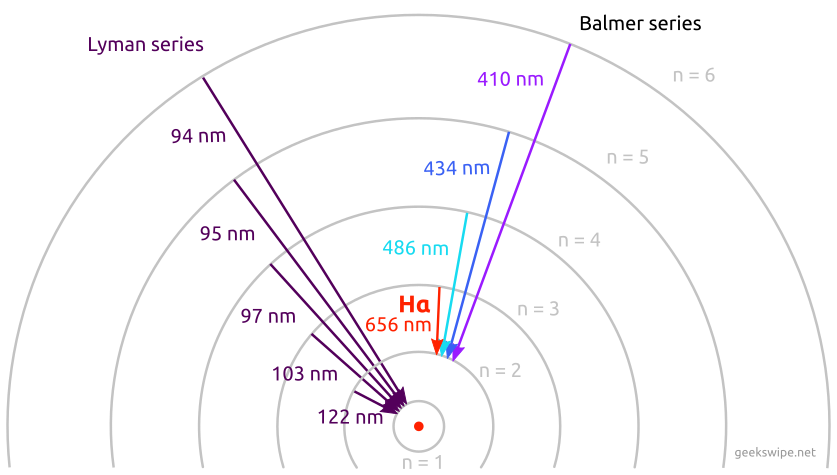

Next, let's take a closer look at the H-alpha transition, which refers is the transition between the first (n=2) and second excited states (n=3) of the hydrogen atom. The energy associated with this transition corresponds to a photon wavelength of $656.28$ nm. This value is the so-called rest wavelength of the transition, $\lambda_{rest}$, i.e., what you measure in the laboratory when you are stationary relative to the H atom(s). The uncertainty on $\lambda_{rest}$ for H$\alpha$ according to NIST is $\pm 0.000003$, so we can treat it as exact. 

The observed wavelength, $\lambda_{obs}$, of a line in the atmopshere of a moving star is given by 

$$\Large \lambda_{obs} = \lambda_{rest}\sqrt{\frac{c + v_r}{c - v_r}}$$

or

$$\Large \lambda_{obs} = \lambda_{rest}\sqrt{\frac{1 + v_r/c}{1 - v_r/c}} \; \; \; \mathrm{(1)}$$

This is the full relavistic solution for the Doppler effect of light. See [this video](https://www.youtube.com/watch?v=0EOWEMZHZpI) for a good derivation, if you are curious. Note, in the video the signs are flipped in the equation above. I.e., the speaker gives

$$\Large \lambda_{obs} = \lambda_{rest}\sqrt{\frac{c - v_r}{c + v_r}}$$

Both are valid. The difference arises because we are defining a positive radial velocity to be in opposite directions. Using Eq 1, discuss with your group what direction I am defining as positive radial velocities. Is it towards or away from the observer? Also, mathematically, there is nothing stopping us from putting in numbers for $v_r$ that give a negative number for the arguement of a square root (remember $\sqrt{-1} \equiv i$). 

If we are dealing with objects that are moving much slower than the speed of light (as will be with most), we simplify Eq. 1 to just

$$\Large \lambda_{obs} \simeq \lambda_{rest} \left(1 + \frac{v_r}{c}\right) \; \; \; (2)$$

For fun: can you derive Eq. (2)? I suggest only doing this at the end if you have time, or on your own time. Not that it is super time consuming or anything, it's just basically a calc II refresher and isn't as important as getting through the rest of the material. #maths

Some added information that may speed things up:
- $\Large \frac{d}{dx}\sqrt{\frac{1+x}{1-x}}$ evaluated at 0 = 1

The radial velocity signal of Earth is $\sim 0.08$ m/s. How much do Eq. 1 and 2 differ? How about for the more extreme case of two Sun-like stars orbiting one another with a semi-major axis of 0.1 AU? This gives an RV signal of $\sim 30,000$ m/s.

Try determining the radial velocity of the star below. Eyeball method is fine, but you're welcome to try a more robust/elegant approach. Is the star moving towards or away from the observer?

$\textit{Aknowledgment}$: The spectra is taken and modified from: https://iopscience.iop.org/article/10.3847/1538-4365/aa656d. 

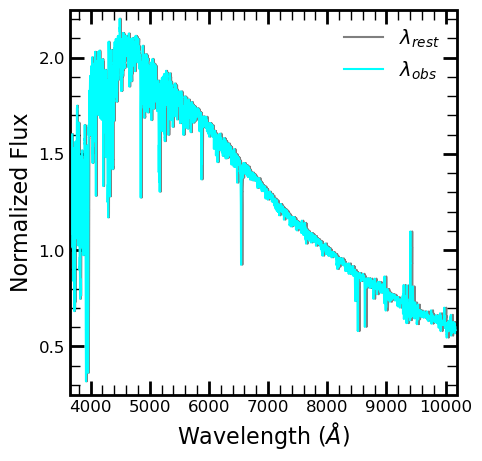

In [3]:
import pandas as pd
spect = pd.read_csv('./data/mock_spectra.csv')

fig, ax = plt.subplots(1,1, figsize = (5,5))
ax.plot(spect['lambda_rest'], spect['flux'], 'k-', alpha = 0.5, label = r'$\lambda_{rest}$')
ax.plot(spect['lambda_obs'], spect['flux'], color = 'cyan', label = r'$\lambda_{obs}$')
ax.set_xlim(min(spect['lambda_rest']), max(spect['lambda_rest']))
ax.set_ylim(0.25,2.25)

ax.tick_params(which = 'major', direction = 'in', top = True, right = True, length = 10, width = 2, labelsize = 12)
ax.tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 7.5, width = 1)

ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth(2)
ax.legend(frameon = False, fontsize = 14)

ax.set_xlabel(r'Wavelength ($\AA$)', fontsize = 16)
ax.set_ylabel(r'Normalized Flux', fontsize = 16)

        
from matplotlib.ticker import MultipleLocator

ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.1))

ax.xaxis.set_major_locator(MultipleLocator(1000))
ax.xaxis.set_minor_locator(MultipleLocator(200))

# RV semi-amplitude

Now that we have a method for measuring the radial velocity of an object at a discrete time, we can measure the radial velocity of said object at different times to create a 'radial velocity curve'. Below are some example RV curves for real exoplanets -- they can and do vary wildly!


![spectrum.png](./figures/rv_curve_examples.png)


Radial velocity curves are complicated functions of several orbital parameters and involve solving a transcendental equation (i.e., it cannot be solved analytically and must be solved numerically). [This pdf](https://sites.astro.caltech.edu/~srk/BlackHoles/Literature/RV_Derivation.pdf) provides derivations of the various equations that go into an RV curve.

For our purposes, we will focus on the key parameter of an RV curve that allows us to determine the mass of a planet (in ideal circumstances): the semi-amplitude, defined as "half of the peak-to-peak amplitude". For a sine function of the form $f(x) = A\times \sin(x)$, the semi-amplitude is just $A$. 

The radial velocity semi-amplitude for a **STAR** as the result of a planet orbiting it is

$$\Large K = \left(\frac{2\pi G}{P}\right)^{1/3}\frac{M_p}{\left(M_p + M_\star\right)^{2/3}}\frac{\sin i}{\sqrt{1-e^2}}$$

Where
    
- $M_\star$ is the mass of the star
- $M_p$ is the mass of the planet
- $P$ is the orbital period of the planet and host star around their mutual COM
- $e$ is the eccentricity of the orbit
- $i$ is the inclination

$K$ is really the fundamental parameter of this technique. If the mass of the star and inclination angle of the planet are known, then we can calculate planet mass. If the inclination angle is unknown then we can only calculate the minimum mass of the planet. Why?

In the limit the $M_\star \gg M_p$, as is often the case, $e=0$ (circular orbit), and $i=\pi/2$ (edge-on orbit), this reduces to:

$$\Large K = \left(\frac{2\pi G}{P}\right)^{1/3}\frac{M_p}{\left(M_\star\right)^{2/3}}$$

With your classmastes, see if you can derive $K$ for a circular, edge-on orbit from the following:
- $F_g = M_\star\frac{v_\star^2}{a_\star}$ where $v_\star$ is the circular orbital velocity of the star with semi-major axis $a_\star$
- $a_p M_p = a_\star M_\star$ where $a_p$ is the semi-major axis of the planet
- Newton's version of Kepler's third law

# RV curve models

The code cell below generates an animated RV curve which also (makes an attempt to) show the orbits of the star and planet. In both cases, the mass of the star is fixed to 1$M_\odot$. The free input parameters are as follows: 

- Mp = mass of the (exo)planet in Earth masses
- inc = the inclination angle of the orbit relative to the observer (in RADIANS).
    - Reminder: an edge on orbit is $i = \pi / 2$ and a face on orbit is $i = 0$.
- e = orbital eccentricity.
    - Reminder: eccentricity measures how much how much the orbit deviates from circular. As such, a circular orbit has e = 0. e$\geq 1$ represent unbound orbits.
- a = the semi-major axis


I want you to explore how planet mass, semi-major axis, eccentricity, and inclination angle change the amplitude and shape of the radial velocity signal. It is currently set up to simulate an object with $M_p = 0.5 M_\odot$, so likely an M dwarf star, and the simulation as shown is a really single-lined spectroscopic binary. I did this so you can see the orbit of the `primary' star. When you start simulating planet sized objects, the orbit of the star will become unresolvable. 

Run the animation as is to start and try to figure out what direction you observing from. Once you've done that, you can set arrow = True and it will show you the direction of the observer. You can change this direction using the optional `w' parameter, measured in radians. These animations take a minute to build, so I have included a few pre-generated ones in the 'pre-loaded animations' folder. Discuss with your group how the inclination angle changes the amplitude of the RV curve and how eccentricity changes the shape + minimum and maximum values. 

Some bugs to be aware of:
- when changing the viewing angle, the current iteration of the code doesn't like it when the eccentricity angle is exactly zero. So, if you want an eccentricity of zero, approximate it as e = 0.001 or some small number.
- I very recently had to change how the arrow is being generated when arrow = True. I think it is working as intended, but I haven't had time to do enough testing.

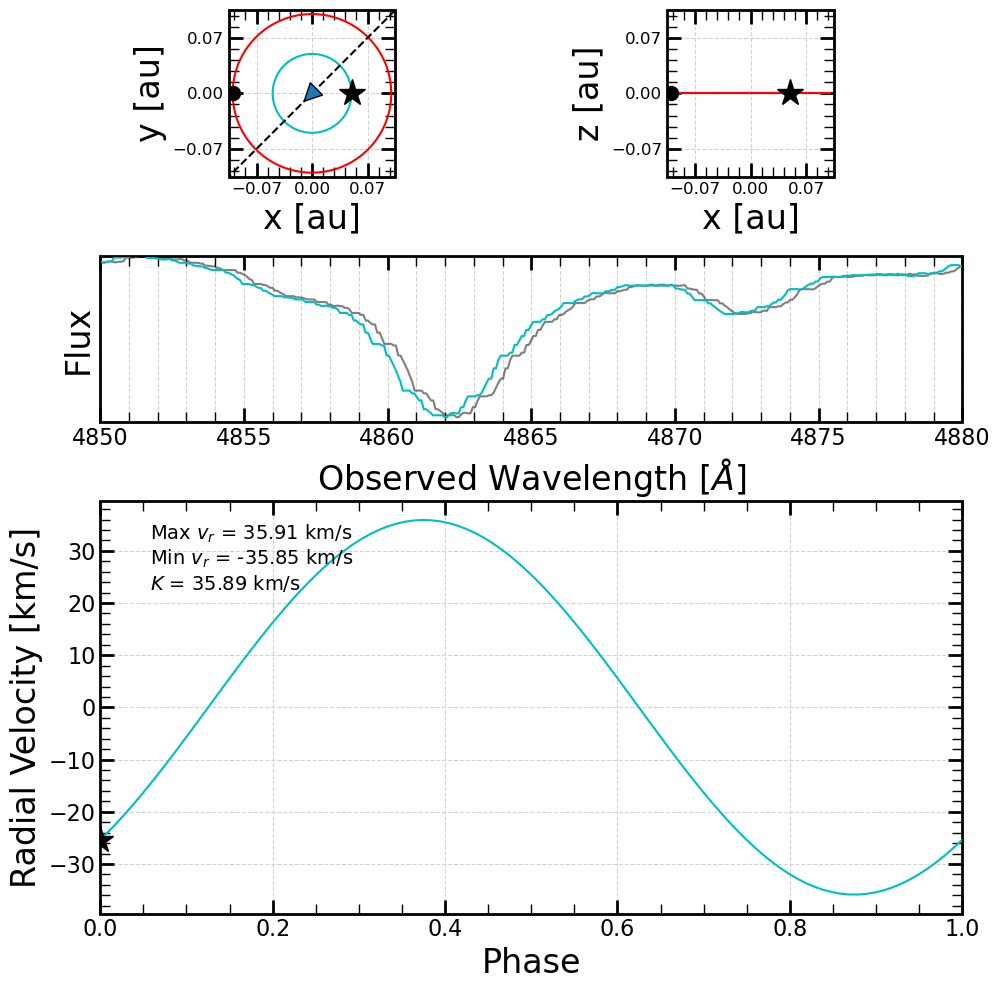

In [4]:
#------------------------------------------User inputs-----------------------------------------------------------------#
Mp = 333054/2.0 #planet mass in Earth masses
a = 0.1 #Semi-major axis in AU
e = 0.001 #eccentricity from 0-1
inc = np.pi/2.0 #inclination angle -- varies from 0 to pi/2 (0 to 90 degrees)
#-----------------------------------------------------------------------------------------------------------------------#

animate_rv_curve(Mp = Mp, a = a, e = e, inc = inc, w = np.pi/4.0, numpts = 100)